In [27]:
# Keep this cell while WIP
%load_ext autoreload
%autoreload 2

In [10]:
import liesel_ptm as ptm
import liesel.goose as gs
import jax
import jax.numpy as jnp
import pandas as pd
import plotnine as p9

In [9]:
key = jax.random.PRNGKey(42)
k1, k2, k3 = jax.random.split(key, 3)

In [17]:
n = 500
x = jax.random.normal(k1, shape=(n,))
e = jax.random.normal(k2, shape=(n,))
y = ptm.PTMLocScaleDataGen.cov3_oscillating(x) + e

df = pd.DataFrame({"y": y, "x": x})

<Axes: xlabel='x', ylabel='y'>

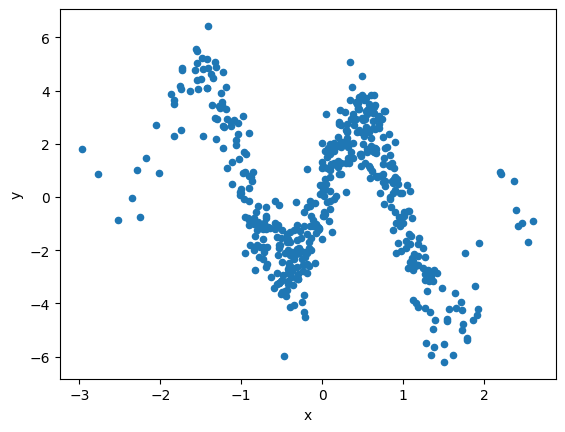

In [18]:
df.plot.scatter("x", "y")

In [66]:
model = ptm.PTMLocScale.from_nparam(
    y, nparam=10
)

model.loc_model += ptm.LinearSmooth(x, name="x_lin")

tau = ptm.ScaleInverseGamma(1.0, concentration=1.0, scale=0.01, name="tau_x")
model.loc_model += ptm.NonlinearPSpline.from_nparam(x, nparam=30, scale=tau, name="x_nonlin")

model, pos = model.optimize_knots()
graph = model.build_graph(optimize_normalization=False)
eb = gs.EngineBuilder(seed=10, num_chains=4)
eb = model.setup_engine_builder(eb, graph, sample_normalization=False)

liesel.model.model - INFO - Converted dtype of Data(name="x_nonlin_coef_transformed_value").value
liesel.model.model - INFO - Converted dtype of Data(name="x_lin_coef_value").value
liesel_ptm.ptm_ls - INFO - Optimizing 2 parameters.
liesel_ptm.ptm_ls - INFO - Finished optimization after 10000 iterations.
liesel_ptm.ptm_ls - INFO - Optimizing parameter block #1 (len=2).
liesel_ptm.ptm_ls - INFO - Finished optimization after 10000 iterations.


In [ ]:
eb.set_duration(warmup_duration=500, posterior_duration=1000)
engine = eb.build()
engine.sample_all_epochs()


In [21]:
results = engine.get_results()
samples = results.get_posterior_samples()

In [22]:
xgrid = jnp.linspace(-5, 5, 301)

In [29]:
fx = model.loc_model.predict(samples, x_lin=xgrid, x_nonlin=xgrid)

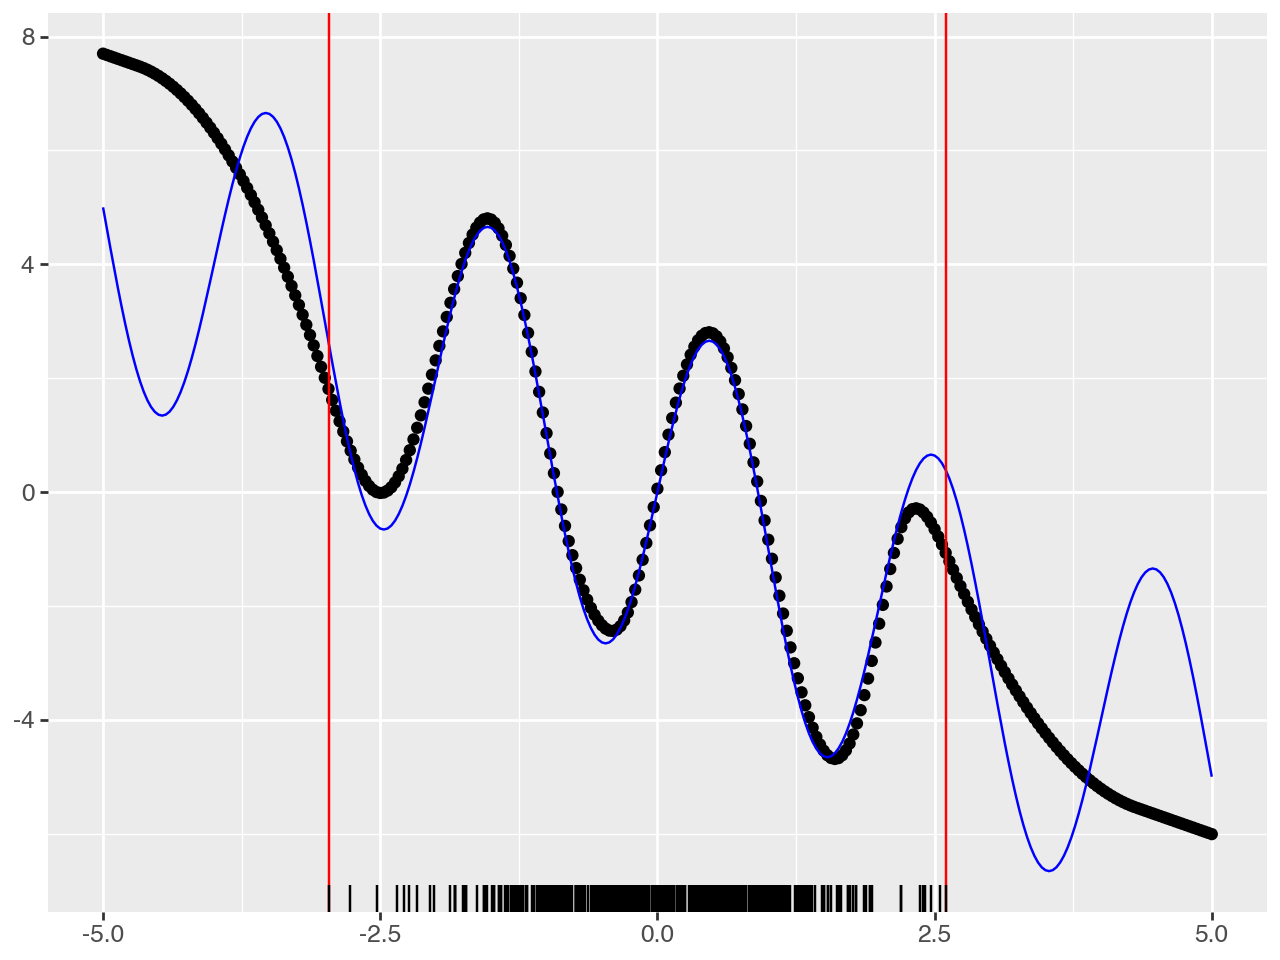

In [34]:
(
    p9.ggplot()
    + p9.geom_point(p9.aes(xgrid, fx.mean(axis=(0, 1))))
    + p9.geom_line(p9.aes(xgrid, ptm.PTMLocScaleDataGen.cov3_oscillating(xgrid)), color="blue")
    + p9.geom_vline(xintercept=x.min(), color="red")
    + p9.geom_vline(xintercept=x.max(), color="red")
    + p9.geom_rug(p9.aes(x), sides="b")
)

In [44]:
gs.Summary(results)

Parameter summary:

                                      kernel      mean            sd  \
parameter                   index                                      
loc_intercept               ()             -  0.086524  2.191636e-03   
scale_intercept_exp         ()             -  0.987135  5.992307e-03   
tau_x2_transformed          ()     kernel_02  1.415985  7.137077e-01   
unscaled_normalization_mean ()             -  3.333648  5.266434e-07   
unscaled_normalization_sd   ()             -  1.000000  1.213763e-07   
x_lin_coef                  (0,)   kernel_00 -0.827798  4.612055e-02   
x_nonlin_coef_transformed   (0,)   kernel_01  0.095272  1.023711e+00   
                            (1,)   kernel_01 -0.184051  9.369930e-01   
                            (2,)   kernel_01 -0.534603  8.365886e-01   
                            (3,)   kernel_01 -0.714457  7.628627e-01   
                            (4,)   kernel_01 -1.009559  7.186322e-01   
                            (5,)   kernel_01 -1.097178  6.557539e-01   
                            (6,)   kernel_01 -0.340003  6.579337e-01   
                            (7,)   kernel_01  0.251763  6.526620e-01   
                            (8,)   kernel_01  1.140399  6.038896e-01   
                            (9,)   kernel_01  0.851320  6.033431e-01   
                            (10,)  kernel_01  0.676123  5.765228e-01   
                            (11,)  kernel_01  1.038590  6.180089e-01   
                            (12,)  kernel_01 -0.285733  6.865870e-01   
                            (13,)  kernel_01 -0.922457  6.894908e-01   
                            (14,)  kernel_01 -0.462491  6.264403e-01   
                            (15,)  kernel_01  0.040613  5.783944e-01   
                            (16,)  kernel_01  0.651399  5.916175e-01   
                            (17,)  kernel_01  1.261350  6.018577e-01   
                            (18,)  kernel_01  0.980267  6.249542e-01   
                            (19,)  kernel_01  0.829560  6.479560e-01   
                            (20,)  kernel_01  0.600868  6.757730e-01   
                            (21,)  kernel_01  0.297442  6.763350e-01   
                            (22,)  kernel_01 -0.974540  7.394867e-01   
                            (23,)  kernel_01 -1.992529  7.660867e-01   
                            (24,)  kernel_01 -0.398320  7.978646e-01   
                            (25,)  kernel_01  0.410980  8.466725e-01   
                            (26,)  kernel_01  0.491767  6.831521e-01   
                            (27,)  kernel_01  0.031837  9.906550e-02   

                                     q_0.05     q_0.5    q_0.95  sample_size  \
parameter                   index                                              
loc_intercept               ()     0.083000  0.086547  0.090148         4000   
scale_intercept_exp         ()     0.978416  0.986603  0.997880         4000   
tau_x2_transformed          ()     0.405276  1.303883  2.773418         4000   
unscaled_normalization_mean ()     3.333647  3.333647  3.333648         4000   
unscaled_normalization_sd   ()     1.000000  1.000000  1.000000         4000   
x_lin_coef                  (0,)  -0.904069 -0.828277 -0.753633         4000   
x_nonlin_coef_transformed   (0,)  -1.585079  0.095852  1.831531         4000   
                            (1,)  -1.744379 -0.174606  1.355970         4000   
                            (2,)  -1.927484 -0.544697  0.861897         4000   
                            (3,)  -1.960671 -0.722831  0.557382         4000   
                            (4,)  -2.169635 -1.012629  0.148968         4000   
                            (5,)  -2.185116 -1.093709 -0.063808         4000   
                            (6,)  -1.412391 -0.337684  0.740656         4000   
                            (7,)  -0.826225  0.257111  1.317150         4000   
                            (8,)   0.131658  1.141066  2.164587         4000   
                           

In [45]:
fx_lin = model.loc_model.x_lin.predict(samples, xgrid)

X = jnp.c_[jnp.ones_like(x), x]

obs_coef = jnp.linalg.inv(X.T @ X) @ X.T @ y
fx_lin_obs = jnp.c_[jnp.zeros_like(xgrid), xgrid] @ obs_coef
print(obs_coef)


[ 0.08651308 -0.82756674]


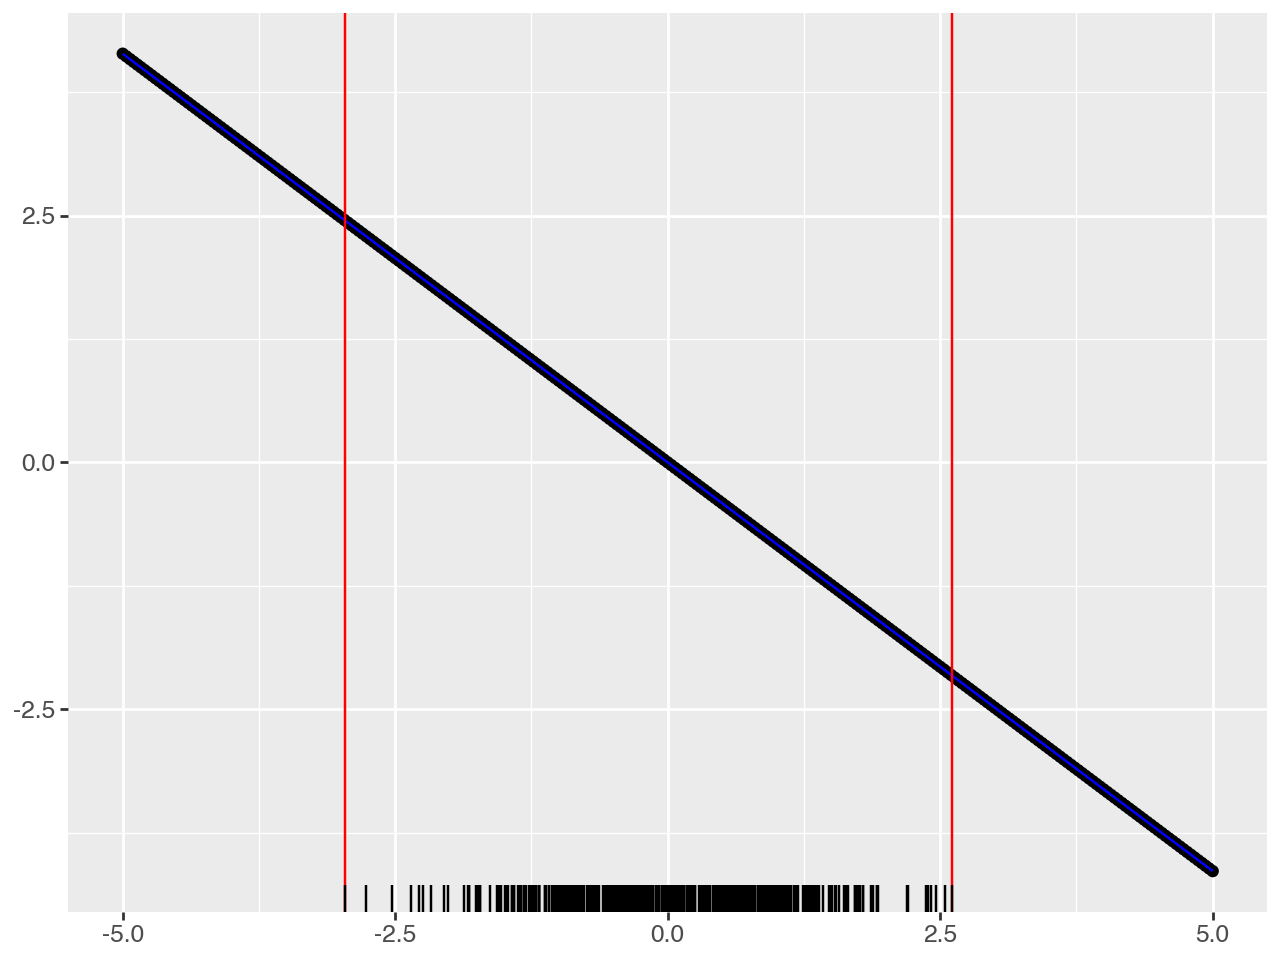

In [42]:
(
    p9.ggplot()
    + p9.geom_point(p9.aes(xgrid, fx_lin.mean(axis=(0, 1))))
    + p9.geom_line(p9.aes(xgrid, fx_lin_obs), color="blue")
    + p9.geom_vline(xintercept=x.min(), color="red")
    + p9.geom_vline(xintercept=x.max(), color="red")
    + p9.geom_rug(p9.aes(x), sides="b")
)

In [75]:
from liesel_ptm.bsplines import BSpline
bspline = model.loc_model.x_nonlin.bspline
model.loc_model.x_nonlin.bspline = BSpline(knots=bspline.knots, eps=0.3, postmultiply_by=bspline.postmultiply_by, target_slope=0.0)

In [76]:
nonlin_summary = model.loc_model.x_nonlin.summarise_by_samples(
    key=jax.random.PRNGKey(87),
    samples=samples,
    x=xgrid
)

In [77]:
nonlin_summary

,value,sample,index,obs,chain,x_nonlin
0,16.166706,0,3383,0,3,-5.000000
1,16.166706,0,3383,1,3,-4.966667
2,16.166706,0,3383,2,3,-4.933333
3,16.166706,0,3383,3,3,-4.900000
4,16.166706,0,3383,4,3,-4.866667
...,...,...,...,...,...,...
30095,4.193267,99,2189,296,2,4.866667
30096,4.193267,99,2189,297,2,4.900001
30097,4.193267,99,2189,298,2,4.933333
30098,4.193267,99,2189,299,2,4.966667


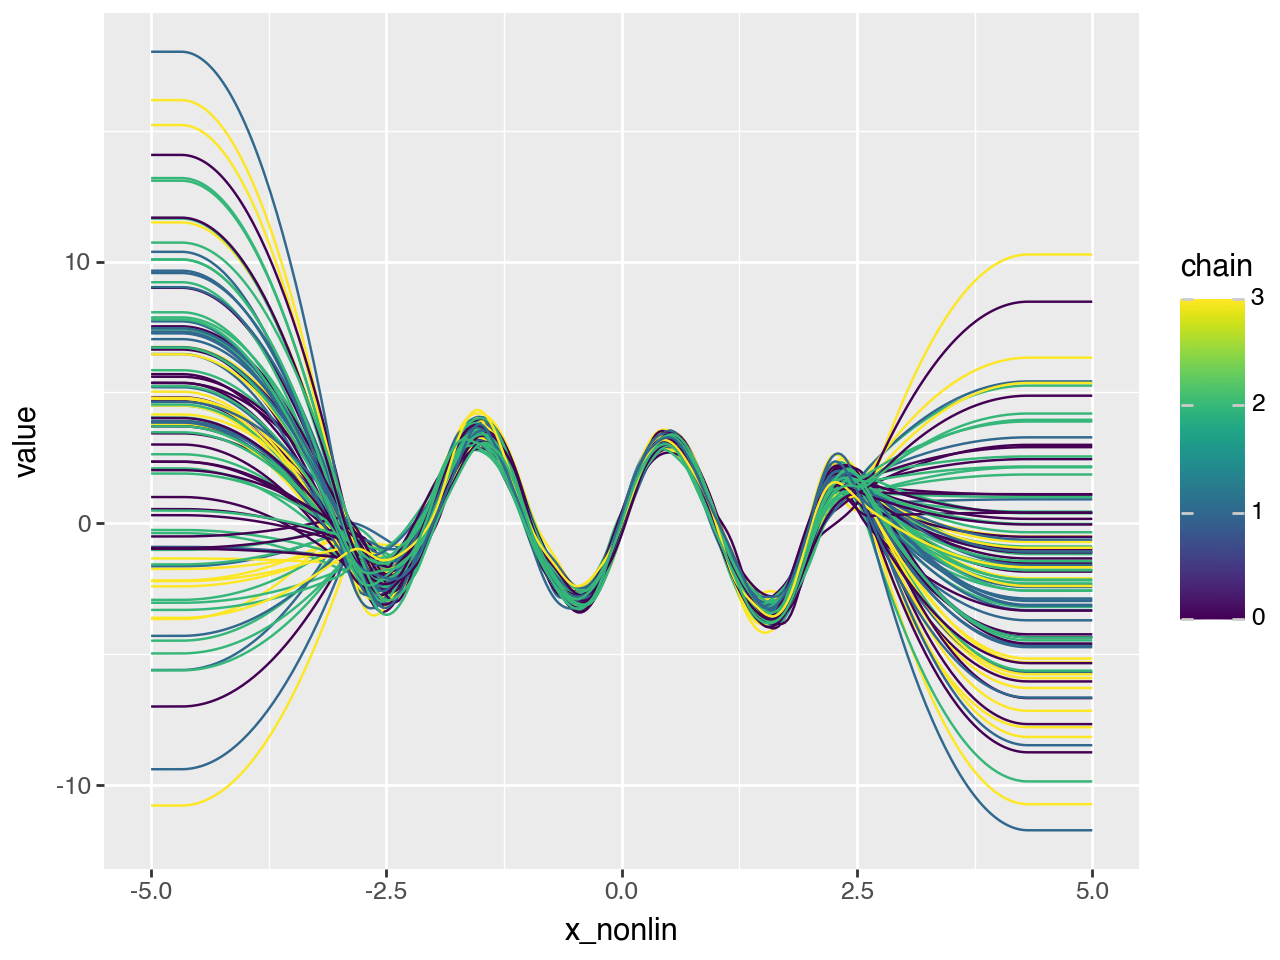

In [78]:
(
    p9.ggplot(nonlin_summary)
    + p9.aes("x_nonlin", "value", color="chain", group="sample")
    + p9.geom_line()
)

In [51]:
nonlin_summary_q = model.loc_model.x_nonlin.summarise_by_quantiles(
    samples=samples,
    x=xgrid
)

In [53]:
nonlin_summary_q

,mean,sd,median,lo,hi,x_value,name
0,3.560047,4.866339,3.584113,-2.678925,9.789847,-5.000000,x_nonlin
1,3.564878,4.868010,3.587159,-2.672494,9.799998,-4.966667,x_nonlin
2,3.569709,4.869687,3.592622,-2.661748,9.809477,-4.933333,x_nonlin
3,3.574540,4.871371,3.602226,-2.652601,9.818254,-4.900000,x_nonlin
4,3.579371,4.873063,3.606026,-2.658437,9.826410,-4.866667,x_nonlin
...,...,...,...,...,...,...,...
296,-1.888021,4.513572,-1.732065,-7.693176,3.791925,4.866667,x_nonlin
297,-1.883190,4.510912,-1.725682,-7.688131,3.797956,4.900001,x_nonlin
298,-1.878359,4.508259,-1.721740,-7.682693,3.799669,4.933333,x_nonlin
299,-1.873528,4.505613,-1.713278,-7.677007,3.795248,4.966667,x_nonlin


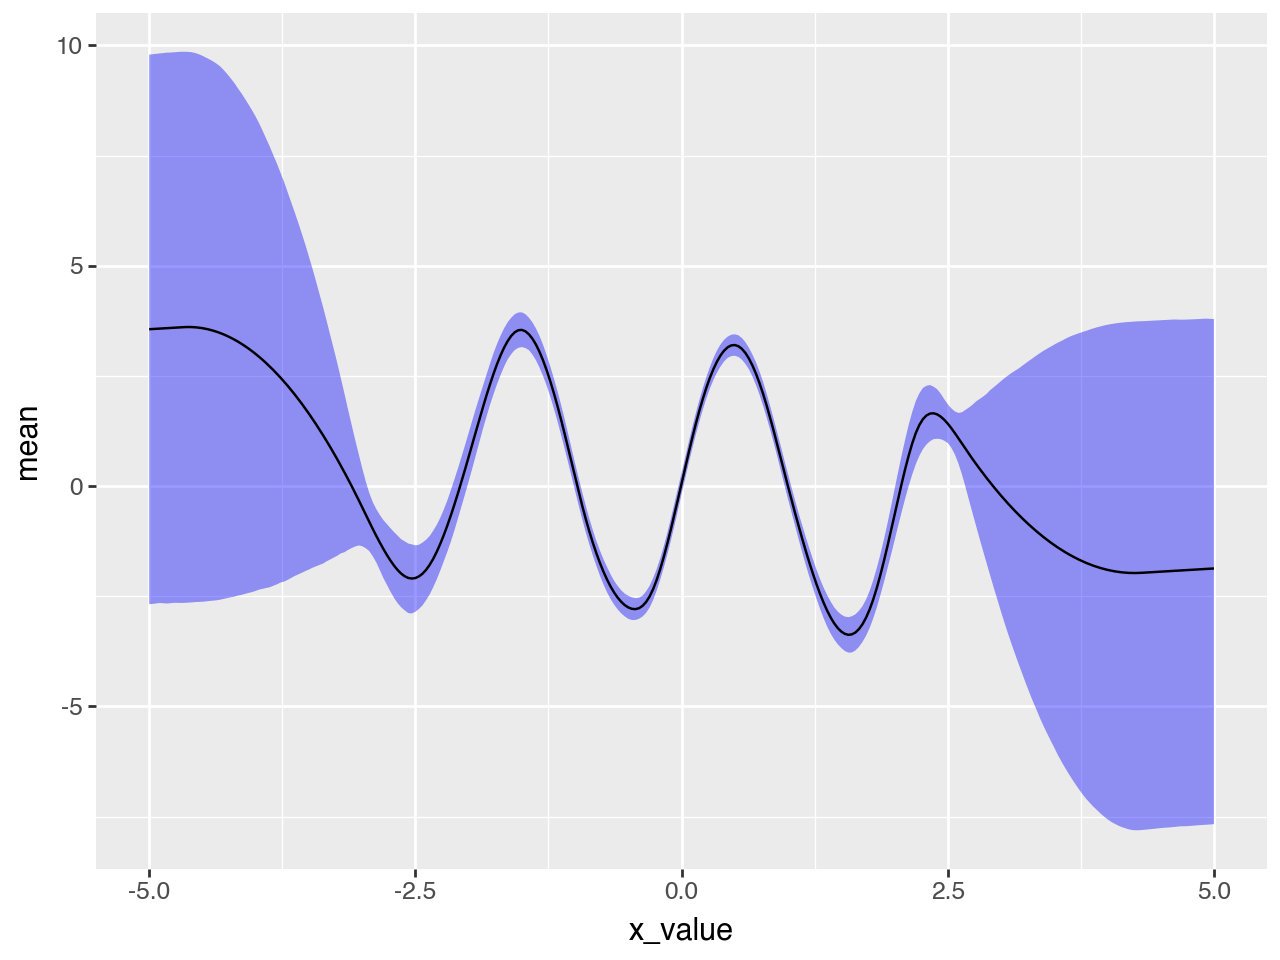

In [55]:
(
    p9.ggplot(nonlin_summary_q)
    + p9.geom_ribbon(p9.aes(x="x_value", ymin="lo", ymax="hi"), fill="blue", alpha=0.4)
    + p9.geom_line(p9.aes("x_value", "mean"))
)